In [1]:
import torch
from torch import nn

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [3]:
import pandas as pd

In [4]:
species = "Adelie"
df = pd.read_csv("penguins_size.csv")
df = df[df["species"] == species][["species", "flipper_length_mm", "body_mass_g", "sex"]]
df

,species,flipper_length_mm,body_mass_g,sex
0,Adelie,181.0,3750.0,MALE
1,Adelie,186.0,3800.0,FEMALE
2,Adelie,195.0,3250.0,FEMALE
3,Adelie,NaN,NaN,NaN
4,Adelie,193.0,3450.0,FEMALE
...,...,...,...,...
147,Adelie,184.0,3475.0,FEMALE
148,Adelie,195.0,3450.0,FEMALE
149,Adelie,193.0,3750.0,MALE
150,Adelie,187.0,3700.0,FEMALE


In [5]:
import matplotlib.pyplot as plt

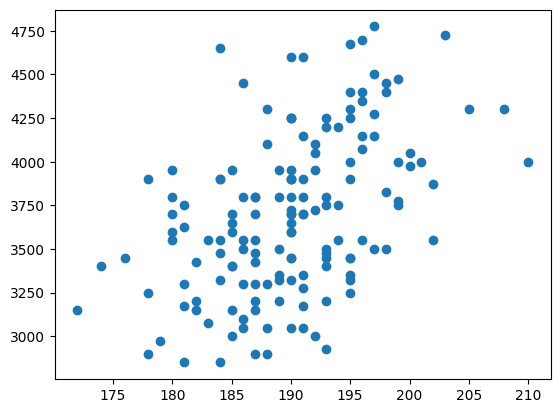

In [6]:
plt.scatter(df['flipper_length_mm'], df['body_mass_g'])
plt.show()

In [7]:
import numpy as np

In [8]:
def predict(x, w, bias):
    return w.dot(x) + bias

In [9]:
df_train = df.head(df.shape[0] // 4 * 3).dropna()
df_test = df.tail(df.shape[0]  - df.shape[0] // 4 * 3).dropna()

In [36]:
x_train = np.array(df_train['flipper_length_mm']).reshape((1, df_train.shape[0]))
y_train = np.array(df_train['body_mass_g']).reshape((1, df_train.shape[0]))
x_test = np.array(df_test['flipper_length_mm']).reshape((1, df_test.shape[0]))
y_test = np.array(df_test['body_mass_g']).reshape((1, df_test.shape[0]))

In [22]:
def mse(a, b):
    return np.square(a - b).mean()

In [33]:
def mse_det_w(a, b, x):
    return 2 * np.dot((a - b).dot(x), np.ones(a.shape[0]) * 2).mean()
def mse_det_b(a, b, x):
    return 2 * np.dot((a - b), np.ones(a.shape[0]) * 2).mean()

In [25]:
a = np.array([[1, 2, 3], [4, 5, 6]], dtype=np.float32)
b = np.array([[1, 3, 2], [7, 3, 2]], dtype=np.float32)

print(mse(a, b))

5.1666665


In [26]:
a = np.array([[1, 2]])
b = np.array([[3, -1]])
print(mse(a, b))

6.5


In [27]:
def random_train(x, y, w, bias, alpha=0.1, epoch=1, log=True):
    for i in range(epoch):
        y_predict = w.dot(x) + bias
        new_w = w + (np.random.rand(*w.shape) * 2 - 1) * alpha
        new_bias = bias + (np.random.rand(*bias.shape) * 2 - 1) * alpha
        y_predict_new = new_w.dot(x) + new_bias
        old_mse = mse(y, y_predict)
        new_mse = mse(y_predict_new, y)
        if old_mse > new_mse:
            if log:
                print(f"Current MSE: {old_mse}; New MSE: {new_mse}; w: {w} -> {new_w}; bias: {bias} -> {new_bias}")
            w = new_w
            bias = new_bias
        elif log:
            print(f"Current MSE: {old_mse}; New MSE: {new_mse}")
    return w, bias

w = np.random.rand(1, 1)
bias = np.random.rand(1)

w, bias = random_train(x_train, y_train, w, bias, alpha=0.1, epoch=1000)

Current MSE: 13685070.923378242; New MSE: 13753754.406168224
Current MSE: 13685070.923378242; New MSE: 13813655.615081916
Current MSE: 13685070.923378242; New MSE: 13563442.133401705; w: [[0.38766207]] -> [[0.47543137]]; bias: [0.4741568] -> [0.42309134]
Current MSE: 13563442.133401705; New MSE: 13589538.695980318
Current MSE: 13563442.133401705; New MSE: 13443337.997098768; w: [[0.47543137]] -> [[0.56210988]]; bias: [0.42309134] -> [0.44509664]
Current MSE: 13443337.997098768; New MSE: 13575519.653468832
Current MSE: 13443337.997098768; New MSE: 13409597.038014846; w: [[0.56210988]] -> [[0.5865892]]; bias: [0.44509664] -> [0.44026231]
Current MSE: 13409597.038014846; New MSE: 13463297.386764273
Current MSE: 13409597.038014846; New MSE: 13462519.157095445
Current MSE: 13409597.038014846; New MSE: 13477920.864913153
Current MSE: 13409597.038014846; New MSE: 13307710.238955244; w: [[0.5865892]] -> [[0.66041918]]; bias: [0.44026231] -> [0.47872795]
Current MSE: 13307710.238955244; New MSE

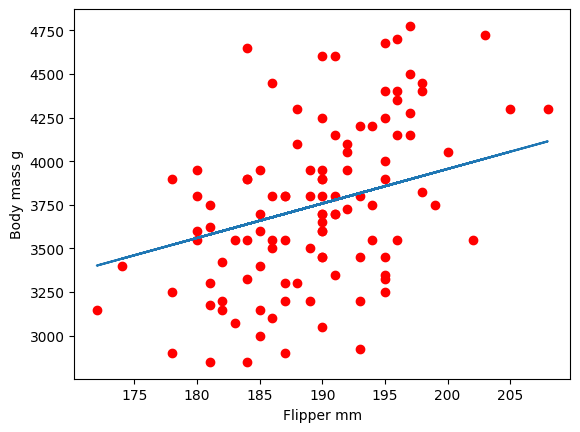

In [29]:
y_predict = w.dot(x_train) + bias
plt.plot(x_train.reshape(df_train.shape[0], 1), y_predict.reshape(df_train.shape[0], 1))
plt.scatter(x_train.reshape(df_train.shape[0], 1), y_train, c="red")
plt.xlabel('Flipper mm')
plt.ylabel('Body mass g')
plt.show()

In [30]:
def branching_search(x, y, w, bias, k = 5, alpha=0.1, epoch=1, log=True):
    for i in range(epoch):
        y_predict = w.dot(x) + bias
        new_w_list = [w + (np.random.rand(*w.shape) * 2 - 1) * alpha for _ in range(k)]
        new_bias_list = [bias + (np.random.rand(*bias.shape) * 2 - 1) * alpha for _ in range(k)]
        y_predict_new_list = [new_w.dot(x) + new_bias for new_w, new_bias in zip(new_w_list, new_bias_list)]
        old_mse = mse(y, y_predict)
        new_mse_list = [mse(y_predict_new, y) for y_predict_new in y_predict_new_list]
        new_mse_i = np.argmin(new_mse_list)
        new_w = new_w_list[new_mse_i]
        new_bias = new_bias_list[new_mse_i]
        new_mse = new_mse_list[new_mse_i]
        if old_mse > new_mse:
            if log:
                print(f"Current MSE: {old_mse}; New MSE: {new_mse}; w: {w} -> {new_w}; bias: {bias} -> {new_bias}")
            w = new_w
            bias = new_bias
        elif log:
            print(f"Current MSE: {old_mse}; New MSE: {new_mse}")
    return w, bias

w = np.random.rand(1, 1)
bias = np.random.rand(1)

w, bias = branching_search(x_train, y_train, w, bias, k=10, alpha=0.1, epoch=1000)

Current MSE: 14023755.584557874; New MSE: 13911632.31940877; w: [[0.144193]] -> [[0.22365112]]; bias: [0.82964408] -> [0.86629582]
Current MSE: 13911632.31940877; New MSE: 13809383.183847345; w: [[0.22365112]] -> [[0.296809]]; bias: [0.86629582] -> [0.82125715]
Current MSE: 13809383.183847345; New MSE: 13716555.149819026; w: [[0.296809]] -> [[0.36375698]]; bias: [0.82125715] -> [0.72463928]
Current MSE: 13716555.149819026; New MSE: 13620752.383146605; w: [[0.36375698]] -> [[0.43258294]]; bias: [0.72463928] -> [0.7211128]
Current MSE: 13620752.383146605; New MSE: 13494648.772237204; w: [[0.43258294]] -> [[0.52348624]]; bias: [0.7211128] -> [0.72900899]
Current MSE: 13494648.772237204; New MSE: 13436847.424934136; w: [[0.52348624]] -> [[0.56582823]]; bias: [0.72900899] -> [0.63176619]
Current MSE: 13436847.424934136; New MSE: 13327190.596502364; w: [[0.56582823]] -> [[0.64585337]]; bias: [0.63176619] -> [0.55256077]
Current MSE: 13327190.596502364; New MSE: 13198113.67795459; w: [[0.6458

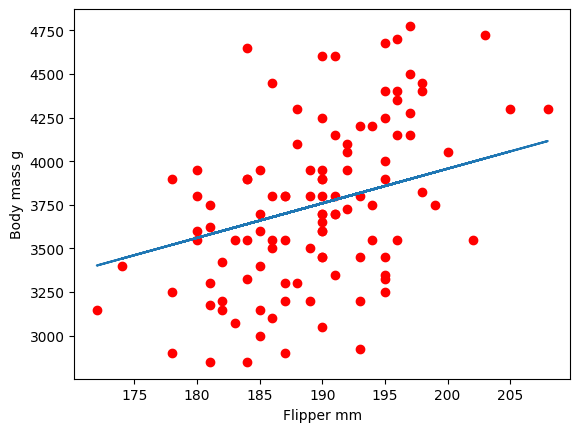

In [ ]:
y_predict = w.dot(x_train) + bias
plt.plot(x_train.reshape(df_train.shape[0], 1), y_predict.reshape(df_train.shape[0], 1))
plt.scatter(x_train.reshape(df_train.shape[0], 1), y_train, c="red")
plt.xlabel('Flipper mm')
plt.ylabel('Body mass g')
plt.show()

In [34]:
import copy
def gde(x, y, w, bias, k = 5, alpha=0.1, epoch=1, log=True):
    for i in range(epoch):
        y_predict = w.dot(x) + bias

        grad_w = mse_det_w(y, y_predict, x)
        grad_b = mse_det_b(y, y_predict, x)

        old_w = copy.deepcopy(w)
        old_b = copy.deepcopy(b)
        
        w = w - grad_w * alpha
        b = b - grad_b * alpha
        if log:
            print(f"Current MSE: {mse(y, y_predict)}; w: {old_w} -> {w}; bias: {old_b} -> {b}")
    return w, bias

w = np.random.rand(1, 1)
bias = np.random.rand(1)

w, bias = branching_search(x_train, y_train, w, bias, k=10, alpha=0.1, epoch=1000)

Current MSE: 13945119.956077334; New MSE: 13804181.112209825; w: [[0.20325342]] -> [[0.30322092]]; bias: [0.21600746] -> [0.30970417]
Current MSE: 13804181.112209825; New MSE: 13667135.13223759; w: [[0.30322092]] -> [[0.40117824]]; bias: [0.30970417] -> [0.35305594]
Current MSE: 13667135.13223759; New MSE: 13555303.41919897; w: [[0.40117824]] -> [[0.48117224]]; bias: [0.35305594] -> [0.44745116]
Current MSE: 13555303.41919897; New MSE: 13433121.78224392; w: [[0.48117224]] -> [[0.56914758]]; bias: [0.44745116] -> [0.5140559]
Current MSE: 13433121.78224392; New MSE: 13305443.633737218; w: [[0.56914758]] -> [[0.66226285]]; bias: [0.5140559] -> [0.44200107]
Current MSE: 13305443.633737218; New MSE: 13205278.771206046; w: [[0.66226285]] -> [[0.73582417]]; bias: [0.44200107] -> [0.34839768]
Current MSE: 13205278.771206046; New MSE: 13094613.678635951; w: [[0.73582417]] -> [[0.81656798]]; bias: [0.34839768] -> [0.40754272]
Current MSE: 13094613.678635951; New MSE: 12996278.934865125; w: [[0.8

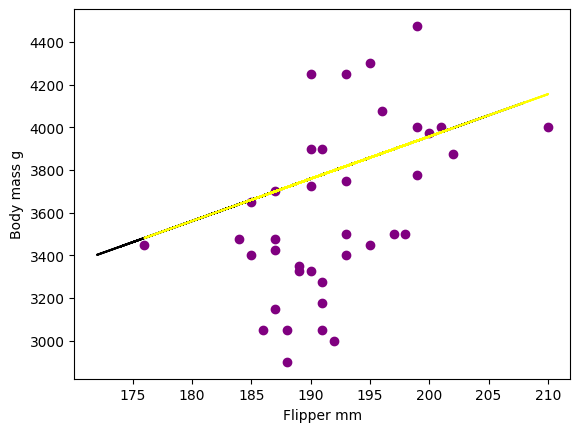

In [42]:
y_predict = w.dot(x_train) + bias
y_predict_test = w.dot(x_test) + bias

plt.plot(x_train.reshape(df_train.shape[0], 1), y_predict.reshape(df_train.shape[0], 1), c="black")
# plt.scatter(x_train.reshape(df_train.shape[0], 1), y_train, c="red")

plt.plot(x_test.reshape(df_test.shape[0], 1), y_predict_test.reshape(df_test.shape[0], 1), c="yellow")
plt.scatter(x_test.reshape(df_test.shape[0], 1), y_test, c="purple")

plt.xlabel('Flipper mm')
plt.ylabel('Body mass g')
plt.show()